[*********************100%***********************]  2 of 2 completed

Training completed. Alpha: 12.791966265500474, Beta: 0.2643876096358398
Total out of sample returns from 2022-01-01 to 2024-01-01: -0.48%


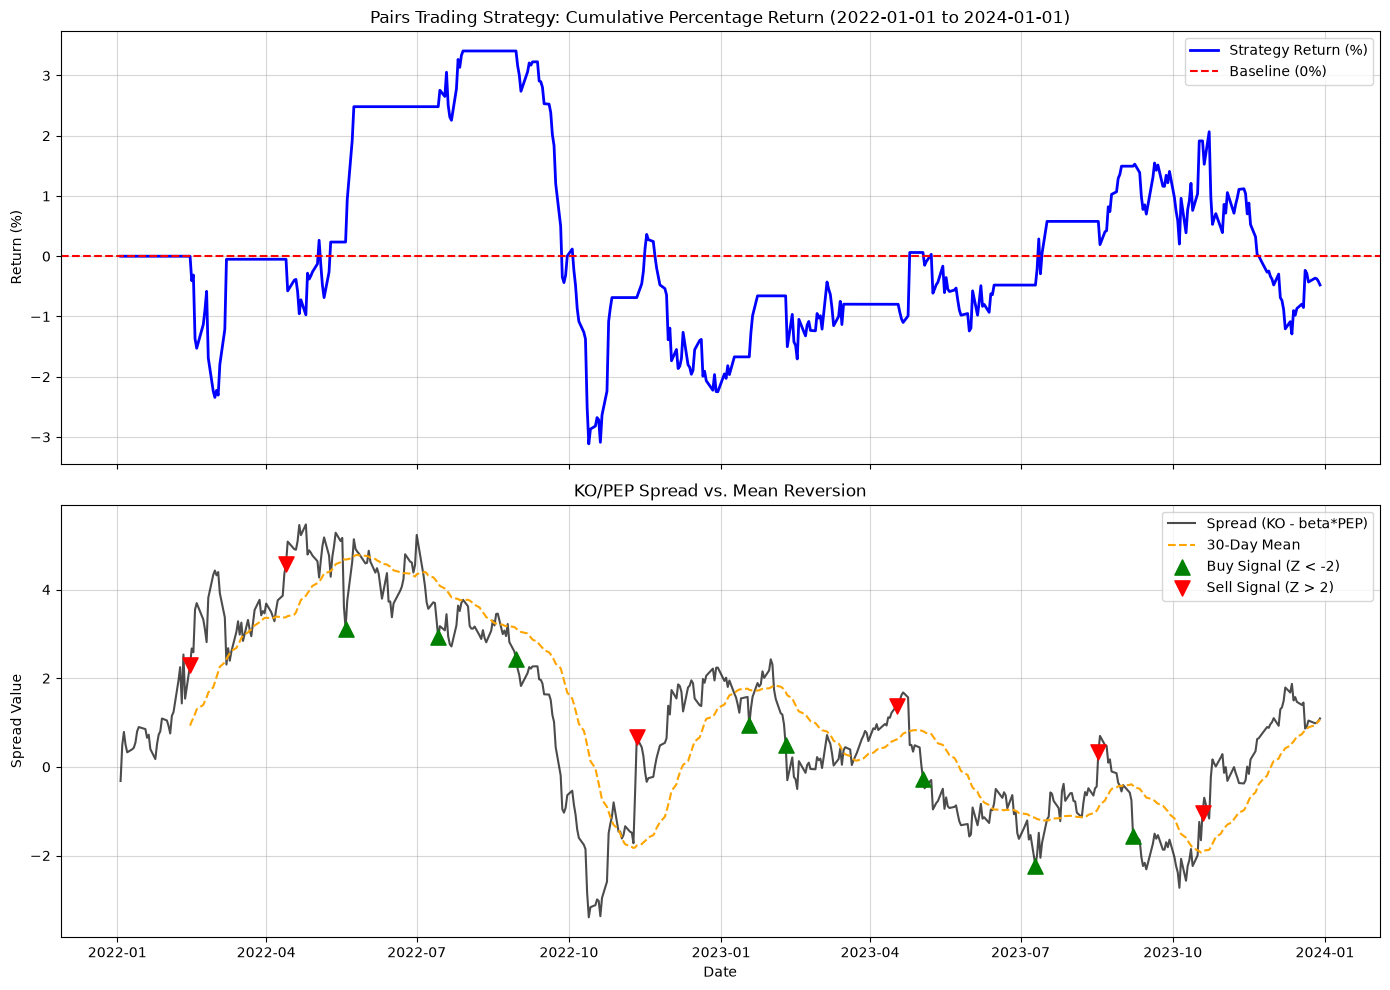

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import sys
import os

sys.path.append(os.path.abspath('../src'))
from data_loader import fetch_multiple_stocks_close
from backtester import backtest_pairs_trading_strategy

tickers = ["KO", "PEP"]
train_start = "2018-01-01"
train_end = "2021-12-31"
test_start = "2022-01-01"
test_end = "2024-01-01"

backtest_pairs_trading_strategy(tickers, train_start, train_end, test_start, test_end)

### Model Evaluation: Initial Implementation

From the return of -0.48% we can see that the strategy was not profitable. However, for the first (statistically correct) implementation of my model, the fact that the return was close to 0 is a positive. It proves that the infrastructure works, and I need to fine tune the logic. 

There are a few reasons why I believe this strategy may be ineffective:

*   **Structural Shift:** My model was trained from 2018-2021. If the equity pair fundamentally changed how they trade relative to each other during the testing period, then the OLS model I calculated was no longer valid. To change this, I should switch from a static test/train split into a rolling OLS, which will allow my hedge ratio to adapt as the relationship evolves.
*   **Trending vs. Mean-Reverting Spread:** The spread may be trending rather than mean-reverting. For example, if the spread starts trending in one direction, the z-score will cause a trade to be made, but the spread keeps widening which will cause a massive loss. I have researched a test called an Augmented-Dickey-Fuller test on the recent spread. It will calculate whether the spread is mean-reverting, and therefore, whether I should enter the trade.
*   **Omission of the Sharpe Ratio:** I also omitted the Sharpe Ratio in this strategy. After some brief research, I realise that the Sharpe Ratio is critical because total return is meaningless without knowing how much risk it took. Because this mean reversion strategy inherently is market-neutral and produces small, consistent returns, it might be helpful to apply leverage to the trades. However, this will only be a sensible thing to do if the strategy has a high Sharpe Ratio (and therefore low volatility).

#### The Sharpe Ratio Formula
The Sharpe Ratio is calculated by the following formula:

$$ \text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p} $$

Where:
*   $R_p$ is the portfolio return
*   $R_f$ is the risk-free rate
*   $\sigma_p$ is the portfolio standard deviation

# **2nd implementation**

Since the first iteration I have made many changes to the backtesting
framework and also computed many different metrics to really help me
understand the relationship between the different stocks.

First and foremost, I added the Sharpe ratio to my backtester, where I
used two different conventions. The first convention uses the formula
already mentions, while the second formula omits the risk-free rate. The
first convention will always give a worse Sharpe ratio because it
calculates the returns of my strategy, compared to a risk-free strategy
of leaving money in the bank and letting interest grow the account. The
second convention assumes that the money would not be stored in such a
way, and that any returns are purely for profit. This convention is
calculated by the formula $\frac{R_p}{\sigma_p}$.

Secondly, I tested all 12 pairs to confirm if they were cointegrated, in
the cointegration_test.ipynb file. I did this by using an Engle-Granger
test, which is based off the ADF test previously talked about. When
calculating multiple p-values at the same time, there is a higher chance
that a value will be lower than the significance level due to sheer
chance. As a result, I adjusted the p-values using a Holm-Bonferroni
test. I then calculated the half-life of all the pairs to ensure that
the time horizon for the equity pair to revert to the mean was tradeable
(i.e. the half-life wasn't too long or too short).

Finally, I optimised the backtester by adding a few more parameters to
the function; namely, the window and half-life. This is because if an
equity pair had a very short half-life, we would want to use a smaller
window, and vice versa. To implement these into my backtest I created
two new function that calculated the half-life and window. I also added
an optional window_multiple parameter in the backtest function in case I
wanted to specify how many half-lives the window spans.

Putting these changes together and implementing these into a table
yielded these results:

# Cointegration and Backtesting Results

| Pair | p-value | Holm-adjusted p-value | Half-life | Total return | Sharpe ratio | Number of trades |
|:---|---:|---:|---:|---:|---:|---:|
| GOOGL/GOOG | 0.015 | 0.168 | 25.440 | 2.820 | -4.062 | 19 |
| V/MA | 0.018 | 0.180 | 31.581 | 13.695 | -0.185 | 16 |
| KO/PEP | 0.026 | 0.236 | 41.096 | -11.141 | -1.214 | 12 |
| BHP/RIO | 0.036 | 0.287 | 48.447 | 17.509 | 0.035 | 13 |
| JPM/BAC | 0.064 | 0.446 | 73.041 | -0.074 | -0.589 | 16 |
| HD/LOW | 0.286 | 1.000 | 93.782 | 2.292 | -0.715 | 14 |
| MSFT/AAPL | 0.558 | 1.000 | 168.170 | 2.349 | -0.321 | 15 |
| WMT/TGT | 0.708 | 1.000 | 224.924 | -23.140 | -0.860 | 12 |
| COP/OXY | 0.720 | 1.000 | 170.950 | 94.223 | 0.774 | 18 |
| XOM/CVX | 0.748 | 1.000 | 299.186 | 7.803 | -0.203 | 14 |
| WFC/USB | 0.803 | 1.000 | 278.589 | -4.322 | -0.460 | 10 |

## Correlation Matrix

| Metric | p-value | Half-life | Sharpe ratio |
|:---|---:|---:|---:|
| **p-value** | 1.00 | 0.98 | 0.33 |
| **Half-life** | 0.98 | 1.00 | 0.27 |
| **Sharpe ratio** | 0.33 | 0.27 | 1.00 |


##### **Note the code for this an be found at the bottom of the cointegration_test notebook**